In [1]:
from pathlib import Path
import tifffile as tiff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import get_confocal_pixel_size, compute_masks, statistical_analysis, get_stat_stars

In [2]:
root = Path("/Volumes/Kur/paper_data_sorted/heatshock/data")
repeat_dirs = [pth for pth in root.iterdir() if pth.is_dir() and not pth.name.startswith('.')]
list_of_sample_paths = []

for repeat_dir in repeat_dirs:
    list_of_sample_paths.extend([pth for pth in repeat_dir.iterdir() if pth.is_dir() and not pth.name.startswith('.')])
print(f'Found {len(list_of_sample_paths)} samples across {len(list_of_sample_paths)} repeats.')

Found 183 samples across 183 repeats.


In [3]:
heat_shock_palette = {"control": "#b8c1cc", "heatshock": "#b04a46"}

In [4]:
measurement_dicts = []

for sample_path in list_of_sample_paths:

    sample_dict = {}

    # print(f'Processing sample: {sample_path.name}')
    splits = sample_path.name.split('__')
    if len(splits) == 2:
        uid, name = splits
        date = "2026-01-14"
    elif len(splits) == 3:
        uid, name, date = splits
    else:
        print(f'Unexpected sample name format: {sample_path.name}')
        continue

    proto_condition, sample_number = name.split('-', 1)

    condition = None
    if "soma" in proto_condition:
        continue
    elif "heatshock" in proto_condition:
        condition = "heatshock"
    elif "control" in proto_condition:
        condition = "control"
    else:
        print(f'Unexpected proto_condition format: {proto_condition}')
        continue

    sample_dict.update({
        'sample_path': sample_path,
        'uid': uid,
        'condition': condition,
        "repeat_date": date,
        'sample_number': sample_number,
        "is_heatshock": True if 'heat' in condition.lower() else False
    })


    print(f'Processing sample: {sample_path.name}')

    pixel_size = get_confocal_pixel_size(sample_path)

    img_rna_actin_path = sample_path / "raw" / "bact_rna.tiff"
    img_granule_path = sample_path / "raw" / "granule.tiff"
    img_rna_nanos_path = sample_path / "raw" / "nos_rna.tiff"
    img_nucleus_path = sample_path / "raw" / "nucleus.tiff"

    seg_granule_path = sample_path / "segmentations" / "granule.tiff"
    seg_nucleus_path = sample_path / "segmentations" / "nucleus.tiff"
    seg_cell_path = sample_path / "segmentations" / "cell.tiff"

    img_rna_actin = tiff.imread(img_rna_actin_path)
    img_granule = tiff.imread(img_granule_path)
    img_rna_nanos = tiff.imread(img_rna_nanos_path)
    # img_nucleus = tiff.imread(img_nucleus_path)

    img_seg_granule = tiff.imread(seg_granule_path)
    img_seg_nucleus = tiff.imread(seg_nucleus_path)
    img_seg_cell = tiff.imread(seg_cell_path)

    mask_cell, mask_nucleus, mask_granule, mask_cytoplasm = compute_masks(
        img_seg_cell, img_seg_nucleus, img_seg_granule, safety_margin=2)

    areas_to_measure = {
        "cytoplasm": mask_cytoplasm,
        "nucleus": mask_nucleus,
        "granules": mask_granule,
        "cell": mask_cell
    }

    images_to_measure = {
        "bactin_rna": img_rna_actin,
        "nanos_rna": img_rna_nanos,
        "granules": img_granule
    }

    for area_name, area_mask in areas_to_measure.items():
        for image_name, image in images_to_measure.items():
            mean_intensity = np.mean(image[area_mask])
            total_intensity = np.sum(image[area_mask])
            area_size = np.sum(area_mask)
            measurement_dict = sample_dict.copy()
            measurement_dict.update({
                "area_name": area_name,
                "marker_name": image_name,
                "mean_intensity": mean_intensity,
                "total_intensity": total_intensity,
                "area_size": area_size,
                "pixel_size": pixel_size,
            })
            measurement_dicts.append(measurement_dict)


Processing sample: e853f6c2__control-26__2026-02-05
Processing sample: 278e7bd9__heatshock-29__2026-02-05
Processing sample: 68f17092__heatshock-10__2026-02-05
Processing sample: 77981656__heatshock-11__2026-02-05
Processing sample: 5425f39c__control-16__2026-02-04
Processing sample: bca011f9__heatshock-18__2026-02-04
Processing sample: e1ab9eae__control-34__2026-02-05
Processing sample: d4e2b358__control-23__2026-02-05
Processing sample: b573d509__control-24__2026-02-05
Processing sample: 7ff9640a__heatshock-16__2026-02-05
Processing sample: 2a297e8a__heatshock-13__2026-02-05
Processing sample: 75e88466__heatshock-9__2026-02-05
Processing sample: c2d540d2__control-32__2026-02-05
Processing sample: cdb42fd7__heatshock-11__2026-02-04
Processing sample: 013a5f6f__control-14__2026-02-04
Processing sample: 385045ad__heatshock-22__2026-02-05
Processing sample: 9582e923__heatshock-23__2026-02-05
Processing sample: d8c1f990__control-5__2026-02-05
Processing sample: 5773ecca__control-22__2026-

In [5]:
df = pd.DataFrame(measurement_dicts)

In [6]:
df.head(5)

,sample_path,uid,condition,repeat_date,sample_number,is_heatshock,area_name,marker_name,mean_intensity,total_intensity,area_size,pixel_size
0,/Volumes/Kur/paper_data_sorted/heatshock/data/...,e853f6c2,control,2026-02-05,26,False,cytoplasm,bactin_rna,5149.379673,331959910,64466,5.030085e-08
1,/Volumes/Kur/paper_data_sorted/heatshock/data/...,e853f6c2,control,2026-02-05,26,False,cytoplasm,nanos_rna,1336.521189,86160175,64466,5.030085e-08
2,/Volumes/Kur/paper_data_sorted/heatshock/data/...,e853f6c2,control,2026-02-05,26,False,cytoplasm,granules,2859.078057,184313326,64466,5.030085e-08
3,/Volumes/Kur/paper_data_sorted/heatshock/data/...,e853f6c2,control,2026-02-05,26,False,nucleus,bactin_rna,4618.717910,24756328,5360,5.030085e-08
4,/Volumes/Kur/paper_data_sorted/heatshock/data/...,e853f6c2,control,2026-02-05,26,False,nucleus,nanos_rna,2639.474813,14147585,5360,5.030085e-08


Show differnt pixel sizes across repeats to check for consistency

/opt/anaconda3/envs/newsam/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 27.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/newsam/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 31.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


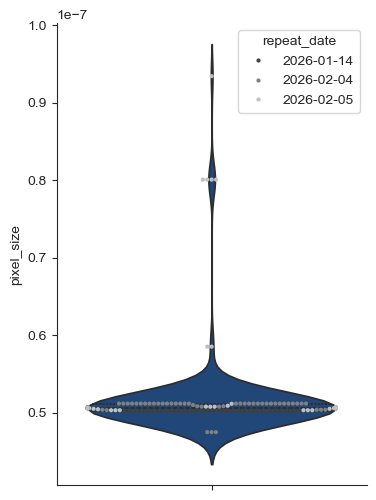

In [7]:
line_thickness = 1.5

# sns.set_style("ticks"), rc={
#     "axes.linewidth": line_thickness,
#     "axes.labelsize": 15,
#     "legend.fontsize": 12,
#     "legend.title_fontsize": 13,
#     "xtick.labelsize": 15,
#     "ytick.labelsize": 15,
#     "xtick.major.width": line_thickness,
#     "ytick.major.width": line_thickness,
# })

sns.set_style("ticks")
# plt.rcParams["axes.linewidth"] = line_thickness
# plt.rcParams["axes.labelsize"] = 15
# plt.rcParams["legend.fontsize"] = 12
# plt.rcParams["legend.title_fontsize"] = 13
# plt.rcParams["xtick.labelsize"] = 15
# plt.rcParams["ytick.labelsize"] = 15
# plt.rcParams["xtick.major.width"] = line_thickness
# plt.rcParams["ytick.major.width"] = line_thickness
# plt.rcParams["axes.labelweight"] = "bold"


df_pixel_size = df.groupby(["uid"])[['pixel_size', "repeat_date"]].first().reset_index()
fig_px_size, ax_px_size = plt.subplots(figsize=(4, 6))
sns.violinplot(data=df_pixel_size, y="pixel_size", ax=ax_px_size, inner="quart", color="#124585")
sns.swarmplot(data=df_pixel_size, y="pixel_size", hue="repeat_date", dodge=False, size=3, palette="grey")
sns.despine()

In [8]:
df_mean_int = df.pivot_table(
    index=['uid', 'condition', 'sample_number', 'is_heatshock', 'marker_name'],
    columns='area_name',
    values='mean_intensity'
).reset_index()
df_mean_int['cytoplasm_to_granule_ratio'] = (
    df_mean_int['cytoplasm'] / df_mean_int['granules']
)
df_mean_int["cytoplasm_to_total_ratio"] = (
    df_mean_int['cytoplasm'] / (df_mean_int['cytoplasm'] + df_mean_int['granules'])
)

df_mean_int = df_mean_int.query("marker_name != 'granules'")

In [9]:
df_mean_int.head(5)

area_name,uid,condition,sample_number,is_heatshock,marker_name,cell,cytoplasm,granules,nucleus,cytoplasm_to_granule_ratio,cytoplasm_to_total_ratio
0,0062b885e11647929eaaceca7ba06389,control,19,False,bactin_rna,4756.127832,3712.489484,18764.290096,2783.510312,0.197849,0.165170
2,0062b885e11647929eaaceca7ba06389,control,19,False,nanos_rna,1602.849193,973.211216,8633.537090,937.476303,0.112725,0.101305
3,013a5f6f,control,14,False,bactin_rna,2376.294668,2270.189489,5017.493972,1944.793477,0.452455,0.311510
5,013a5f6f,control,14,False,nanos_rna,2152.170133,1059.018586,9934.377660,2837.436039,0.106601,0.096332
6,018c2435,control,2,False,bactin_rna,2700.236085,2153.655532,6884.986767,2746.888520,0.312805,0.238272


Statistical Test Results (Cytoplasm to Granule Ratio):
bactin_rna:
    Mean_ratio: 0.5381
    test_type: Mann-Whitney U test
    statistic: 1410.0
    p_value: 2.280935686482643e-10
    Sample_size_heatshock: 82
    Sample_size_control: 81
    star_significance: ***
nanos_rna:
    Mean_ratio: 0.6616
    test_type: Mann-Whitney U test
    statistic: 2112.0
    p_value: 6.043076056956363e-05
    Sample_size_heatshock: 82
    Sample_size_control: 81
    star_significance: ***
Representative UIDs for each condition:
control: ['b7aa987c', 'e96d6bb9', '87b0d7e5']
heatshock: ['c396b3ee', '385045ad', '664fbbc0', '5a0255ae', 'b39c539c']


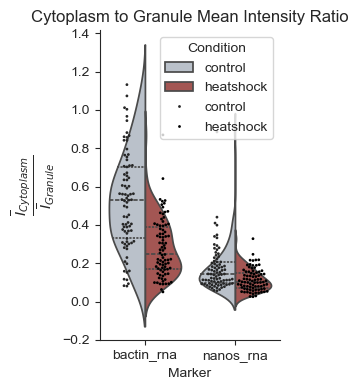

In [15]:
fig_mean_cyto_gran, ax_mean_cyto_gran = plt.subplots(figsize=(3, 4))
sns.violinplot(data=df_mean_int,
               x="marker_name",
               y="cytoplasm_to_granule_ratio",
               hue="condition",
               ax=ax_mean_cyto_gran,
               palette=heat_shock_palette, inner="quart", split=True,
               density_norm="width")
sns.swarmplot(data=df_mean_int,
              x="marker_name",
              y="cytoplasm_to_granule_ratio",
              hue="condition",
              ax=ax_mean_cyto_gran,
              dodge=True, size=2, palette='dark:k')
sns.despine()
ax_mean_cyto_gran.set_title("Cytoplasm to Granule Mean Intensity Ratio")
ax_mean_cyto_gran.set_ylabel(r"$\frac{\overline{I}_{Cytoplasm}}{\overline{I}_{Granule}}$", fontsize=15)
ax_mean_cyto_gran.set_xlabel("Marker")
ax_mean_cyto_gran.legend(title="Condition")
plt.tight_layout()

plt.savefig(root.parent / "cytoplasm_to_granule_ratio_violinplot.pdf", bbox_inches='tight')

# Statistical tests
stat_results = {}
for marker in df_mean_int['marker_name'].unique():
    heatshock_values = df_mean_int[(df_mean_int['marker_name'] == marker) & (df_mean_int['is_heatshock'])]['cytoplasm_to_granule_ratio']
    control_values = df_mean_int[(df_mean_int['marker_name'] == marker) & (~df_mean_int['is_heatshock'])]['cytoplasm_to_granule_ratio']
    stat_rna_results = {
        "Mean_ratio": round(heatshock_values.mean() / control_values.mean(),4) if control_values.mean() != 0 else np.inf,
        "test_type": statistical_analysis(heatshock_values, control_values)[0],
        "statistic": statistical_analysis(heatshock_values, control_values)[1],
        "p_value": statistical_analysis(heatshock_values, control_values)[2],
        "Sample_size_heatshock": len(heatshock_values),
        "Sample_size_control": len(control_values),
        "star_significance": get_stat_stars(statistical_analysis(heatshock_values, control_values)[2])}

    stat_results[marker] = stat_rna_results
print("Statistical Test Results (Cytoplasm to Granule Ratio):")
for marker, results in stat_results.items():
    print(f"{marker}:")
    for key, value in results.items():
        print(f"    {key}: {value}")


# Get uids for representative images in each condition
rep_min = 38
rep_max = 62
representative_uids = {}
for condition in df_mean_int['condition'].unique():
    condition_df = df_mean_int[df_mean_int['condition'] == condition]
    condition_representatives = None
    for marker in ["bactin_rna", "nanos_rna"]:
        marker_df = condition_df[condition_df['marker_name'] == marker]
        marker_min = np.percentile(marker_df['cytoplasm_to_granule_ratio'], rep_min)
        marker_max = np.percentile(marker_df['cytoplasm_to_granule_ratio'], rep_max)
        representative_df = marker_df[(marker_df['cytoplasm_to_granule_ratio'] >= marker_min) & (marker_df['cytoplasm_to_granule_ratio'] <= marker_max)]
        if condition_representatives is None:
            condition_representatives = representative_df['uid'].tolist()
        else:
            # Take the intersection of representative samples across markers
            condition_representatives = list(set(condition_representatives) & set(representative_df['uid'].tolist()))
    representative_uids[condition] = condition_representatives
print("Representative UIDs for each condition:")
for condition, uids in representative_uids.items():
    print(f"{condition}: {uids}")





Statistical Test Results (Cytoplasm to Total Ratio):
bactin_rna:
        Mean_ratio: 0.6438
        test_type: t-test
        statistic: -7.321296064747363
        Sample_size_heatshock: 82
        Sample_size_control: 81
        p_value: 1.1078460520957917e-11
        star_significance: ***
nanos_rna:
        Mean_ratio: 0.7137
        test_type: Mann-Whitney U test
        statistic: 2112.0
        Sample_size_heatshock: 82
        Sample_size_control: 81
        p_value: 6.043076056956363e-05
        star_significance: ***


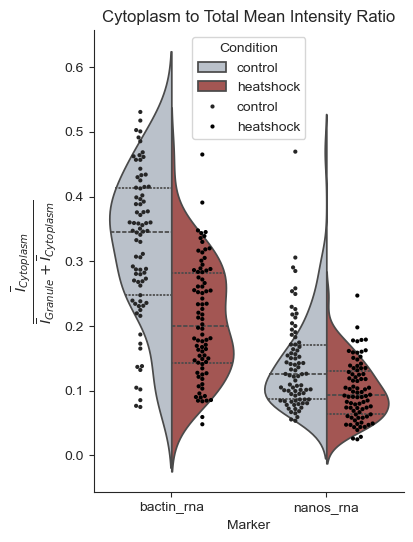

In [11]:
fig_mean_cyto_total, ax_mean_cyto_total = plt.subplots(figsize=(4, 6))
sns.violinplot(data=df_mean_int,
               x="marker_name",
               y="cytoplasm_to_total_ratio",
               hue="condition",
               ax=ax_mean_cyto_total,
               palette=heat_shock_palette, inner="quart", split=True,
               density_norm="width")
sns.swarmplot(data=df_mean_int,
              x="marker_name",
              y="cytoplasm_to_total_ratio",
              hue="condition",
              ax=ax_mean_cyto_total,
              dodge=True, size=3, palette='dark:k')
sns.despine()
ax_mean_cyto_total.set_title("Cytoplasm to Total Mean Intensity Ratio")
ax_mean_cyto_total.set_ylabel(r"$\frac{\overline{I}_{Cytoplasm}}{\overline{I}_{Granule} + \overline{I}_{Cytoplasm}}$", fontsize=15)
ax_mean_cyto_total.set_xlabel("Marker")
ax_mean_cyto_total.legend(title="Condition")

plt.savefig(root.parent / "cytoplasm_to_total_ratio_violinplot.pdf", bbox_inches='tight')

# Get statistical test results for cytoplasm to total ratio
stat_results_total = {}
for marker in df_mean_int['marker_name'].unique():
    heatshock_values = df_mean_int[(df_mean_int['marker_name'] == marker) & (df_mean_int['is_heatshock'])]['cytoplasm_to_total_ratio']
    control_values = df_mean_int[(df_mean_int['marker_name'] == marker) & (~df_mean_int['is_heatshock'])]['cytoplasm_to_total_ratio']
    stat_rna_results_total = {
        "Mean_ratio": round(heatshock_values.mean() / control_values.mean(),4) if control_values.mean() != 0 else np.inf,
        "test_type": statistical_analysis(heatshock_values, control_values)[0],
        "statistic": statistical_analysis(heatshock_values, control_values)[1],
        "Sample_size_heatshock": len(heatshock_values),
        "Sample_size_control": len(control_values),
        "p_value": statistical_analysis(heatshock_values, control_values)[2],
        "star_significance": get_stat_stars(statistical_analysis(heatshock_values, control_values)[2])}
    stat_results_total[marker] = stat_rna_results_total
print("Statistical Test Results (Cytoplasm to Total Ratio):")
for marker, results in stat_results_total.items():
    print(f"{marker}:")
    for key, value in results.items():
        print(f"        {key}: {value}")